In [1]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import imdb
from keras import models, layers, optimizers, losses, metrics
from sklearn.metrics import mean_absolute_error

In [2]:
# 1. Load the IMDB dataset
# Keep only the top 10,000 most frequent words
NUM_WORDS = 10000
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=NUM_WORDS)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
train_labels

array([1, 0, 0, ..., 0, 1, 0])

In [4]:

# 2. Decode a sample review (optional)
word_index = imdb.get_word_index()
reverse_word_index = {value + 3: key for key, value in word_index.items()}
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"


decoded_review = ' '.join([reverse_word_index.get(i, '?') for i in train_data[0]])
print("Sample Decoded Review:\n", decoded_review)


1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Sample Decoded Review:
 <START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to the two little boy's that played the <UNK> of norman and paul they were just brilliant children are often left out of the <UNK> list i think because the stars that play them all grown up are such a big profile for th

In [5]:

# 3. Vectorize input data
def vectorize_sequences(sequences, dimension=NUM_WORDS):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
      #One hot encoding for checking presence of
        results[i, sequence] = 1.0
    return results

X_train = vectorize_sequences(train_data)
X_test = vectorize_sequences(test_data)
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')


In [6]:
# 4. Prepare validation set
X_val = X_train[:10000]
partial_X_train = X_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]


In [7]:
# 5. Build the model
model = models.Sequential([
    layers.Dense(16, activation='relu', input_shape=(NUM_WORDS,)), #fully connected layer
    layers.Dense(16, activation='relu'), # hidden layer
    layers.Dense(1, activation='sigmoid') # output layer
])



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
# 6. Compile the model
model.compile(
    optimizer=optimizers.RMSprop(learning_rate=0.001),
    loss=losses.binary_crossentropy,
    metrics=[metrics.binary_accuracy]
)


In [9]:
# 7. Train the model
history = model.fit(
    partial_X_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(X_val, y_val)
)
history.history

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - binary_accuracy: 0.7013 - loss: 0.5828 - val_binary_accuracy: 0.8640 - val_loss: 0.3748
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - binary_accuracy: 0.8916 - loss: 0.3204 - val_binary_accuracy: 0.8678 - val_loss: 0.3276
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - binary_accuracy: 0.9198 - loss: 0.2363 - val_binary_accuracy: 0.8857 - val_loss: 0.2851
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - binary_accuracy: 0.9414 - loss: 0.1847 - val_binary_accuracy: 0.8886 - val_loss: 0.2756
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - binary_accuracy: 0.9516 - loss: 0.1501 - val_binary_accuracy: 0.8700 - val_loss: 0.3295
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - binary_accuracy: 0.9555 - loss: 0.1357 - val_binary_accuracy: 0.8876 - val_loss: 0.2934
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - binary_accuracy: 0.9685 - loss: 0.1087 - val_binary_accuracy: 0.8838 - val_loss: 0.3025
Epoch 8/20
30

{'binary_accuracy': [0.7824666500091553,
  0.8977333307266235,
  0.921999990940094,
  0.9402666687965393,
  0.9492666721343994,
  0.95660001039505,
  0.9666666388511658,
  0.9731333255767822,
  0.9768666625022888,
  0.9812666773796082,
  0.98580002784729,
  0.9887999892234802,
  0.9905333518981934,
  0.9941999912261963,
  0.9964666962623596,
  0.9951333403587341,
  0.9965333342552185,
  0.996999979019165,
  0.9968000054359436,
  0.9998000264167786],
 'loss': [0.5034027099609375,
  0.3021434247493744,
  0.22911614179611206,
  0.1831279695034027,
  0.15217067301273346,
  0.13241779804229736,
  0.11045805364847183,
  0.09470172226428986,
  0.08053170889616013,
  0.06899271160364151,
  0.058145422488451004,
  0.04942861571907997,
  0.041575703769922256,
  0.033392101526260376,
  0.029276538640260696,
  0.02659405767917633,
  0.022730907425284386,
  0.019398599863052368,
  0.018200762569904327,
  0.009102610871195793],
 'val_binary_accuracy': [0.8640000224113464,
  0.8677999973297119,
  0.8

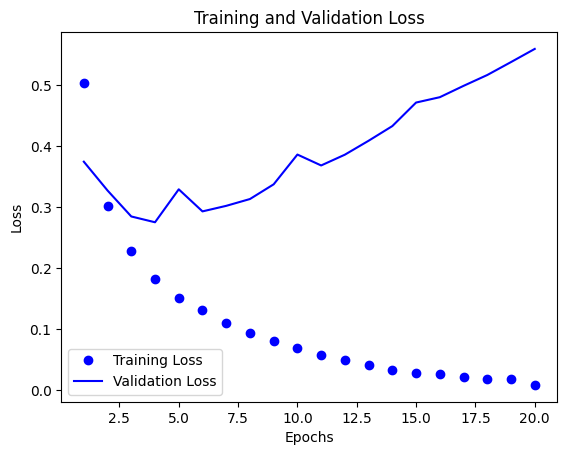

In [10]:
# 8. Plot training and validation loss
history_dict = history.history
epochs = range(1, len(history_dict['loss']) + 1)

# plt.figure(figsize=(12, 5))
# plt.subplot(1, 2, 1)
plt.plot(epochs, history_dict['loss'], 'bo', label='Training Loss')
plt.plot(epochs, history_dict['val_loss'], 'b', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()


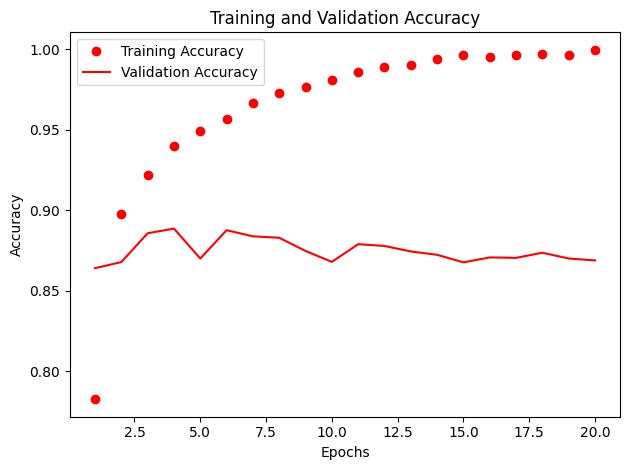

In [11]:
# 9. Plot training and validation accuracy
# plt.subplot(1, 2, 2)
plt.plot(epochs, history_dict['binary_accuracy'], 'ro', label='Training Accuracy')
plt.plot(epochs, history_dict['val_binary_accuracy'], 'r', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# 10. Evaluate on test data
results = model.evaluate(X_test, y_test)
print(f"\nTest Loss: {results[0]:.4f}, Test Accuracy: {results[1]:.4f}")

# 11. Predict on test data
predictions = model.predict(X_test)
y_pred = (predictions > 0.5).astype("int").flatten()

# 12. Calculate Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)
print(f"\nMean Absolute Error on Test Set: {mae:.4f}")